In [12]:
pip install openpyxl



   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [13]:
df = pd.read_excel("C:\\Users\\Harshith\\Manipal\\MSIS_2\\Adavanced-Machine_Learning_Application_Developer_Structure\\EM_Algo\\Data\\marketing_campaign.xlsx")

print(df.head())


     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [14]:
# Create Age column
df["Age"] = 2024 - df["Year_Birth"]

# Remove columns not useful for Gaussian modeling
df = df.drop(columns=[
    "ID",
    "Year_Birth",
    "Education",
    "Marital_Status",
    "Dt_Customer",
    "Z_CostContact",
    "Z_Revenue"
])

# Fill missing Income values
df["Income"] = df["Income"].fillna(df["Income"].median())


In [15]:
features = [
    "Income",
    "Age",
    "MntWines",
    "MntMeatProducts",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

X = df[features].values


In [16]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [33]:
k = 8   # number of customer segments

n, d = X.shape

# Random initialization
means = X[np.random.choice(n, k, replace=False)]
covariances = [np.cov(X.T) for _ in range(k)]
weights = np.ones(k) / k

iterations = 300

for step in range(iterations):

    # ---------- E STEP ----------
    responsibilities = np.zeros((n, k))

    for i in range(k):
        rv = multivariate_normal(means[i], covariances[i])
        responsibilities[:, i] = weights[i] * rv.pdf(X)

    responsibilities /= responsibilities.sum(axis=1, keepdims=True)

    # ---------- M STEP ----------
    Nk = responsibilities.sum(axis=0)

    weights = Nk / n

    means = np.dot(responsibilities.T, X) / Nk[:, np.newaxis]

    new_covariances = []

    for i in range(k):
        diff = X - means[i]
        cov = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]
        cov += 1e-6 * np.eye(d)   # regularization
        new_covariances.append(cov)

    covariances = new_covariances


In [34]:
cluster_labels = np.argmax(responsibilities, axis=1)
df["Segment"] = cluster_labels


In [35]:
segment_summary = df.groupby("Segment")[features].mean()
print(segment_summary)


                Income        Age    MntWines  MntMeatProducts  \
Segment                                                          
0         30310.015579  51.393175   14.228487        11.648368   
1         44482.402010  56.236181  106.972362        45.949749   
2         40317.235294  52.941176  672.235294       163.058824   
3         57637.791165  57.831325  384.568273       127.891566   
4        188891.750000  54.625000   80.875000       145.250000   
5         84576.921053  52.157895  387.684211       771.210526   
6         68240.204082  57.198980  817.219388       263.688776   
7         76739.372093  56.453488  598.883721       497.369767   

         NumWebPurchases  NumStorePurchases  NumWebVisitsMonth  
Segment                                                         
0               1.562315           2.836795           6.434718  
1               3.369347           4.160804           6.248744  
2               2.764706           2.294118          11.882353  
3             

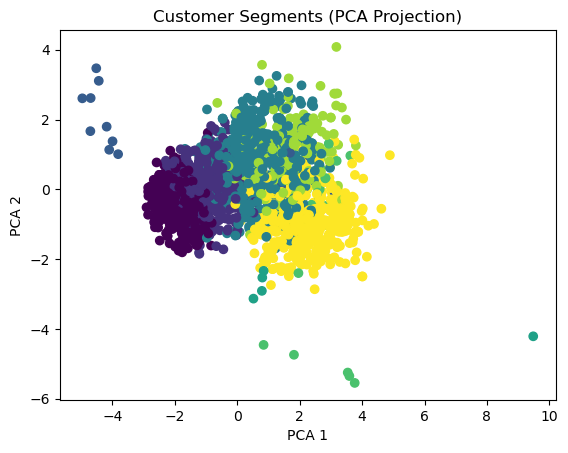

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='viridis')
plt.title("Customer Segments (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


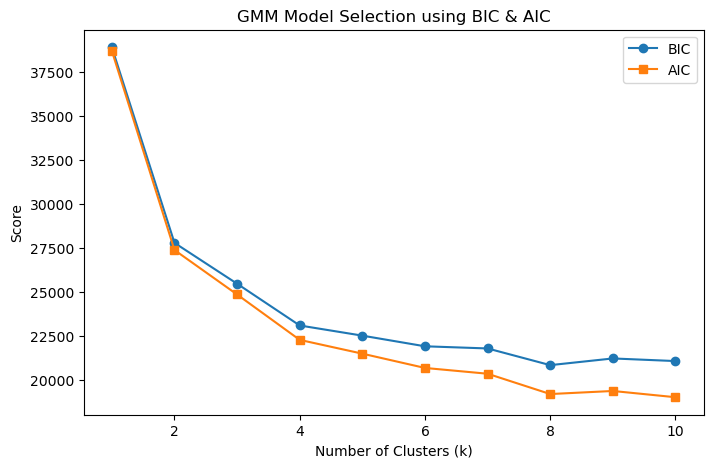

In [32]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

bic_scores = []
aic_scores = []

k_range = range(1, 11)  # test 1 to 10 clusters

for k in k_range:
    gmm = GaussianMixture(n_components=k, 
                          covariance_type='full',
                          random_state=42)
    gmm.fit(X)
    
    bic_scores.append(gmm.bic(X))
    aic_scores.append(gmm.aic(X))

# Plot results
plt.figure(figsize=(8,5))
plt.plot(k_range, bic_scores, marker='o', label="BIC")
plt.plot(k_range, aic_scores, marker='s', label="AIC")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.title("GMM Model Selection using BIC & AIC")
plt.legend()
plt.show()
